# 因果推論 入門 — 練習問題 模範解答(Colab実行版)

データサイエンス3年次 / ハンズオン補助ノートブック

このノートブックは、本編ノートブック末尾の **練習問題1〜4** の模範解答です。
各問は単独で実行できるよう、必要なデータ生成を内部に含めています(本編を先に走らせていなくてもOK)。

> **使い方:** 「ランタイム → すべてのセルを実行」、または各セルで Shift+Enter。
> 追加インストールは不要です。

---

### 取り上げる練習問題
1. `true_effect` を `0` にすると、各手法のATE推定はどうなるか?
2. やる気→点数の係数 `30` を `5` に下げると、素朴な差のバイアスはどう変わるか?
3. 交絡因子をもう1つ(`study_hours`)追加し、回帰に入れ忘れ/入れたときで X の係数を比べる
4. `Y ~ X` だけのモデルでなぜ交絡を補正できないのか(DAGで説明)


In [4]:
# matplotlibの日本語対応ライブラリをインストール
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 45.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=4d0aa6c2ac30f4a3acc4e53f97b22af5e82ab784ac44cfb1cb81f5843e5c80e4
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


## 0. 共通の準備とデータ生成関数

本編と同じ「やる気が交絡する世界」を、パラメータを変えて何度も作れるよう **関数化** します。
こうしておくと、問1・問2で係数だけ差し替えて比較できます。


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import japanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False


def make_data(true_effect=5, motiv_coef=30, n=1000, seed=42):
    """やる気が交絡する世界を生成する。

    true_effect : 講座の真の因果効果(点)
    motiv_coef  : やる気が点数に与える係数(交絡の強さ)
    """
    rng = np.random.default_rng(seed)
    motivation = rng.uniform(0, 1, n)
    p_take = 0.2 + 0.6 * motivation
    X = (rng.uniform(0, 1, n) < p_take).astype(int)
    Y = 50 + motiv_coef * motivation + true_effect * X + rng.normal(0, 5, n)
    return pd.DataFrame(dict(motivation=motivation, X=X, Y=Y))


def estimate_all(df):
    """4つの推定量(素朴な差・層別化・回帰調整・IPW)をまとめて返す。"""
    # 素朴な差
    naive = df[df.X==1].Y.mean() - df[df.X==0].Y.mean()

    # 層別化(やる気の中央値で高低2分割し、人数で加重平均)
    grp = np.where(df.motivation >= df.motivation.median(), "high", "low")
    diffs, weights = [], []
    for g in np.unique(grp):
        sub = df[grp==g]
        diffs.append(sub[sub.X==1].Y.mean() - sub[sub.X==0].Y.mean())
        weights.append(len(sub))
    strat = np.average(diffs, weights=weights)

    # 回帰調整
    reg = smf.ols("Y ~ X + motivation", df).fit().params["X"]

    # 傾向スコア IPW
    ps = smf.logit("X ~ motivation", df).fit(disp=False).predict(df)
    w = np.where(df.X==1, 1/ps, 1/(1-ps))
    y1 = np.average(df[df.X==1].Y, weights=w[df.X==1])
    y0 = np.average(df[df.X==0].Y, weights=w[df.X==0])
    ipw = y1 - y0

    return {"素朴な差": naive, "層別化": strat, "回帰調整": reg, "IPW": ipw}


print("準備OK: make_data() と estimate_all() を定義しました")

準備OK: make_data() と estimate_all() を定義しました


---
## 問1. `true_effect` を `0` にすると、各手法のATE推定はどうなる?

> **問題:** 真の効果を0(=講座は点数に一切影響しない)にして再実行すると、
> 各手法のATE推定はどうなる? 素朴な差は0でなく正の値が出るはず ― なぜ?

### 解答方針
真の効果を0にしても、**交絡経路(やる気→X と やる気→Y)は残っている** ため、
素朴な差は依然として正のバイアスを示します。一方、交絡を調整する3手法は0付近に戻ります。


In [7]:
df0 = make_data(true_effect=0)      # 効果ゼロの世界
res0 = estimate_all(df0)

print("真の因果効果 = 0 点 のとき\n")
for k, v in res0.items():
    print(f"  {k:8s}: {v:+.2f}")


真の因果効果 = 0 点 のとき

  素朴な差    : +5.78
  層別化     : +1.51
  回帰調整    : -0.01
  IPW     : -0.07


### 結果の解釈

- **素朴な差は +6〜7点 程度の正の値** になります。講座の効果は0なのに差が出るのは、
  「やる気の高い人ほど受講し、かつ点数も高い」という交絡が丸ごと差に紛れ込むからです。
  これは **因果効果ではなく、ただの選択バイアス** です。
- **層別化・回帰調整・IPW は ほぼ0** に戻ります。やる気を揃える(調整する)と、
  講座そのものの効果=0 が正しく見えてきます。
  (※層別化だけはやや値が残ることがあります。中央値で高/低の2分割しかしていないため、
  各ビンの中にまだやる気の差が残るからです。ビンを増やすと0に近づきます ― これも良い気づきです。)

**教訓:** 「群間に差があること」と「処置に効果があること」は別物。
交絡があれば、効果ゼロでも差は生まれる。


      true_effect=0  true_effect=5
素朴な差           5.78          10.78
層別化            1.51           6.51
回帰調整          -0.01           4.99
IPW           -0.07           4.93


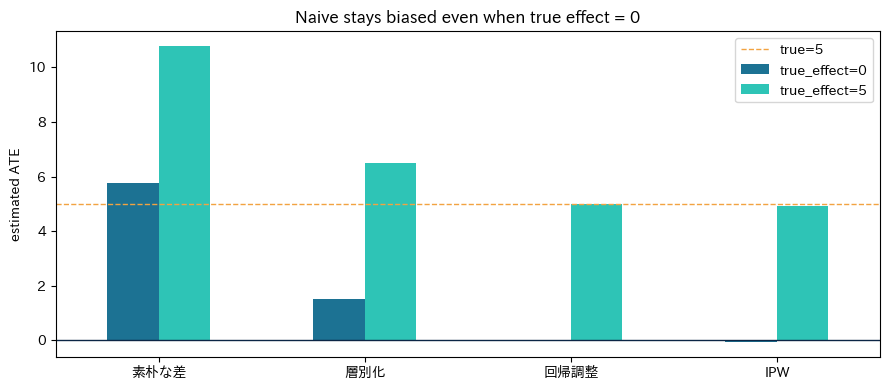

In [8]:
# 効果あり(+5)の世界と並べて比較すると違いが鮮明
df5 = make_data(true_effect=5)
res5 = estimate_all(df5)

compare = pd.DataFrame({"true_effect=0": res0, "true_effect=5": res5}).round(2)
print(compare)

# 可視化
ax = compare.plot(kind="bar", figsize=(9,4), color=["#1C7293","#2EC4B6"])
ax.axhline(0, color="#0B2545", lw=1)
ax.axhline(5, color="#F2A341", ls="--", lw=1, label="true=5")
ax.set_ylabel("estimated ATE"); ax.set_title("Naive stays biased even when true effect = 0")
plt.xticks(rotation=0); plt.legend(); plt.tight_layout(); plt.show()

---
## 問2. やる気→点数の係数を `30 → 5` に下げると、素朴な差のバイアスはどう変わる?

> **問題:** やる気が点数に与える係数 `30` を `5` に下げると、素朴な差のバイアスはどう変わる?

### 解答方針
バイアスの大きさは「交絡因子が **結果Y** にどれだけ効くか」に比例します。
やる気→Y の係数を小さくすれば、交絡経路が細くなり、素朴な差は真値に近づくはずです。
真の効果は +5 に固定し、`motiv_coef` だけを変えて比較します。


In [9]:
results = []
for coef in [30, 20, 10, 5, 0]:
    df = make_data(true_effect=5, motiv_coef=coef)
    naive = df[df.X==1].Y.mean() - df[df.X==0].Y.mean()
    results.append({"motiv_coef(やる気→Y)": coef,
                    "素朴な差": round(naive, 2),
                    "バイアス(=素朴な差−5)": round(naive - 5, 2)})

tbl = pd.DataFrame(results)
print("真の効果は +5 に固定。やる気→Yの係数だけを変える\n")
print(tbl.to_string(index=False))

真の効果は +5 に固定。やる気→Yの係数だけを変える

 motiv_coef(やる気→Y)  素朴な差  バイアス(=素朴な差−5)
                30 10.78           5.78
                20  8.87           3.87
                10  6.96           1.96
                 5  6.00           1.00
                 0  5.04           0.04


### 結果の解釈

- 係数が **30 → 5 と小さくなるにつれ、素朴な差は真値+5に近づき、バイアスが縮む** はずです。
- 係数を **0**(やる気が点数に全く効かない)にすると、素朴な差はほぼ+5になります。
  このとき「やる気」はもはや交絡因子ではありません ― **Yに効かない変数は交絡を生まない** からです。

**交絡バイアスの直感:** バイアス ≈(やる気がXに効く強さ)×(やる気がYに効く強さ)。
**両方の経路が揃って初めて** バイアスが生まれます。


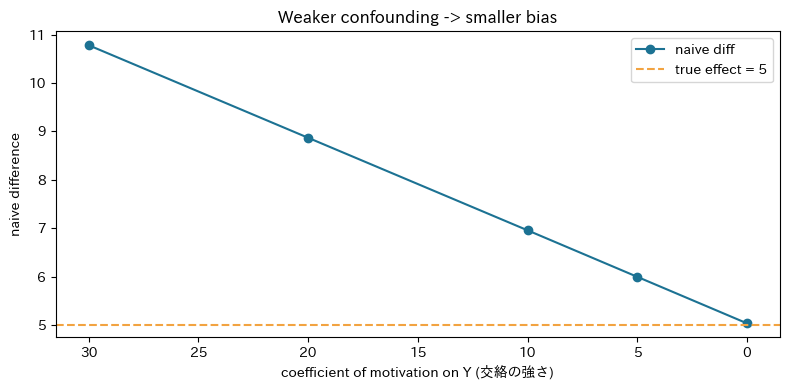

In [10]:
plt.figure(figsize=(8,4))
plt.plot(tbl["motiv_coef(やる気→Y)"], tbl["素朴な差"], "o-", color="#1C7293", label="naive diff")
plt.axhline(5, color="#F2A341", ls="--", label="true effect = 5")
plt.xlabel("coefficient of motivation on Y (交絡の強さ)")
plt.ylabel("naive difference")
plt.title("Weaker confounding -> smaller bias")
plt.gca().invert_xaxis()
plt.legend(); plt.tight_layout(); plt.show()

---
## 問3. 交絡因子をもう1つ追加 ― 入れ忘れ vs 入れたとき

> **問題:** 交絡因子をもう1つ(例: `study_hours`)追加し、X と Y の両方に影響させて、
> 回帰に入れ忘れたときと入れたときで X の係数を比べてみよう。

### 解答方針
やる気に加えて **勉強時間 (study_hours)** も交絡因子にします。
- 勉強する人ほど受講しやすい(study_hours → X)
- 勉強する人ほど点数が高い(study_hours → Y)

回帰式に study_hours を **入れ忘れると** その分の交絡が X の係数に残り、過大評価になります。


In [11]:
def make_data_2confounders(true_effect=5, n=1000, seed=7):
    rng = np.random.default_rng(seed)
    motivation  = rng.uniform(0, 1, n)
    study_hours = rng.uniform(0, 10, n)     # 第2の交絡因子: 0〜10時間/週

    # 受講確率は「やる気」と「勉強時間」の両方で上がる
    score = -0.5 + 1.5*motivation + 0.15*study_hours
    p_take = 1 / (1 + np.exp(-score))       # ロジスティックで 0〜1 に
    X = (rng.uniform(0,1,n) < p_take).astype(int)

    # 点数も両方の交絡因子に依存
    Y = 50 + 20*motivation + 2.0*study_hours + true_effect*X + rng.normal(0,5,n)
    return pd.DataFrame(dict(motivation=motivation, study_hours=study_hours, X=X, Y=Y))


df3 = make_data_2confounders(true_effect=5)

m_none = smf.ols("Y ~ X", df3).fit()                              # 交絡を一切入れない
m_one  = smf.ols("Y ~ X + motivation", df3).fit()                 # 片方だけ(入れ忘れ)
m_both = smf.ols("Y ~ X + motivation + study_hours", df3).fit()   # 両方入れる(正しい)

print(f"真の因果効果 = +5 点\n")
print(f"  調整なし            X係数 : {m_none.params['X']:.2f}")
print(f"  motivationのみ調整   X係数 : {m_one.params['X']:.2f}  ← study_hoursを入れ忘れ")
print(f"  両方とも調整        X係数 : {m_both.params['X']:.2f}  ← 真値+5に一致 ✓")

真の因果効果 = +5 点

  調整なし            X係数 : 9.77
  motivationのみ調整   X係数 : 7.34  ← study_hoursを入れ忘れ
  両方とも調整        X係数 : 4.76  ← 真値+5に一致 ✓


### 結果の解釈

- **調整なし** … 2つの交絡が両方残り、最も過大評価。
- **motivationのみ** … 改善はするが、**study_hoursの分の交絡が残る** ため、まだ+5より大きい。
- **両方** … 真値+5にほぼ一致。

**教訓:** 交絡因子は1つ調整すれば済むとは限らない。
**Xにも Yにも効く変数は、たとえ見落としていても1つ残らずバイアスを生む。**
「どの変数を入れるべきか」を決めるのは統計ではなく、**領域知識とDAG** です。


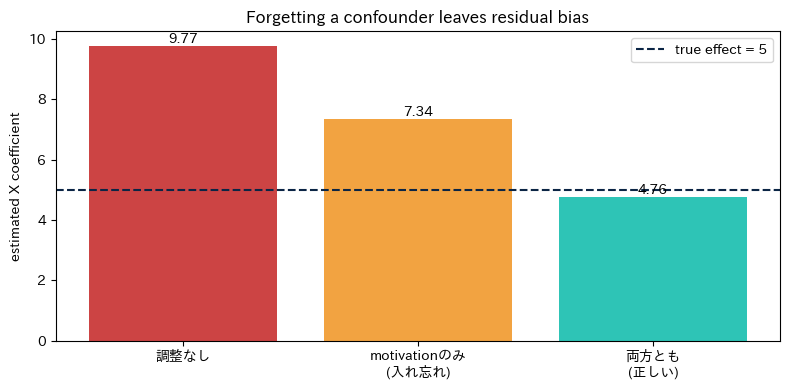

In [12]:
# 3モデルのX係数を可視化
labels = ["調整なし", "motivationのみ\n(入れ忘れ)", "両方とも\n(正しい)"]
vals   = [m_none.params['X'], m_one.params['X'], m_both.params['X']]
colors = ["#C44","#F2A341","#2EC4B6"]

plt.figure(figsize=(8,4))
bars = plt.bar(labels, vals, color=colors)
plt.axhline(5, color="#0B2545", ls="--", label="true effect = 5")
plt.ylabel("estimated X coefficient")
plt.title("Forgetting a confounder leaves residual bias")
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.2f}", ha="center")
plt.legend(); plt.tight_layout(); plt.show()

---
## 問4. なぜ `Y ~ X` だけでは交絡を補正できないのか(DAGで説明)

> **問題:** `motivation` を回帰式から**わざと外した** `Y ~ X` だけのモデルでは、
> なぜ交絡を補正できないのか、DAG(やる気→X, やる気→Y)を描いて説明しよう。

### 解答(言葉での説明)

DAG は次の構造です:

```
        やる気 (Z)
        ↙        ↘
      受講 X  →  点数 Y
```

X と Y の間には **2本の経路** があります。

1. **因果経路** `X → Y` … 講座が点数を上げる、本当に知りたい効果。
2. **裏口経路 (backdoor path)** `X ← やる気 → Y` … やる気を介した「見せかけ」のつながり。

`Y ~ X` の単回帰の係数は、この **2本を合わせた関連** を測ってしまいます。
裏口経路を塞ぐには、その途中にある **やる気で条件付ける(回帰に入れる)** 必要があります。
回帰式から `motivation` を外すと裏口経路が開いたままになり、係数は因果効果より大きくなります。
これが **バックドア基準** の考え方です。

### コードでの確認


In [13]:
df4 = make_data(true_effect=5, motiv_coef=30)

m_backdoor_open   = smf.ols("Y ~ X", df4).fit()              # 裏口経路が開いたまま
m_backdoor_closed = smf.ols("Y ~ X + motivation", df4).fit() # やる気で塞ぐ

print(f"真の因果効果 = +5 点\n")
print(f"  Y ~ X              (裏口あけたまま) : {m_backdoor_open.params['X']:.2f}")
print(f"  Y ~ X + motivation (裏口を塞ぐ)     : {m_backdoor_closed.params['X']:.2f}")
print("\n→ motivationを入れて初めて、係数が真の因果効果+5に一致する")

真の因果効果 = +5 点

  Y ~ X              (裏口あけたまま) : 10.78
  Y ~ X + motivation (裏口を塞ぐ)     : 4.99

→ motivationを入れて初めて、係数が真の因果効果+5に一致する


### DAGの図(matplotlibで描画)

裏口経路が「開いている / 塞がれている」状態を並べて示します。


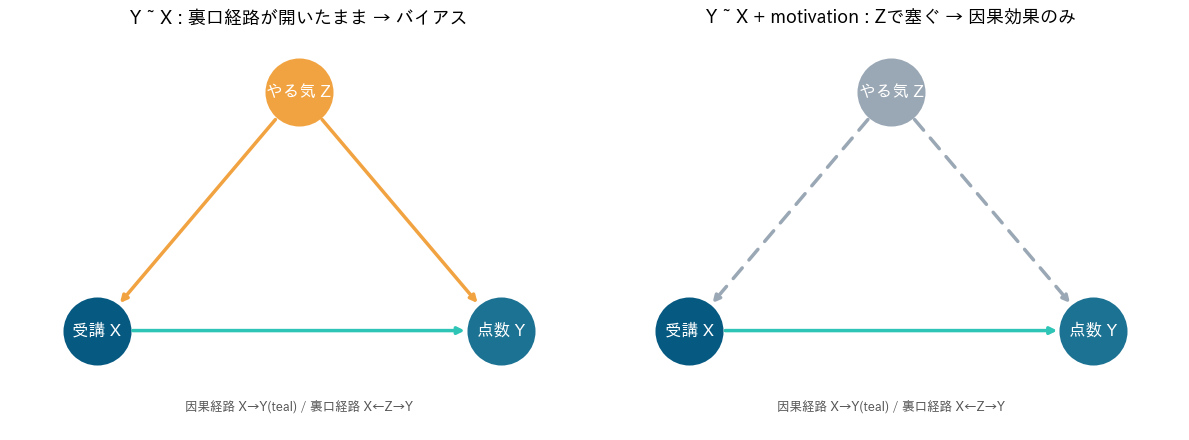

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

def draw_dag(ax, conditioned, title):
    # ノード座標
    pos = {"Z": (0.5, 0.85), "X": (0.15, 0.25), "Y": (0.85, 0.25)}
    # やる気ノードは条件付けると灰色(=塞いだ印)
    z_color = "#9AA7B4" if conditioned else "#F2A341"
    for name,(x,y) in pos.items():
        c = {"X":"#065A82","Y":"#1C7293","Z":z_color}[name]
        ax.scatter(x, y, s=2600, c=c, zorder=3, edgecolors="white", linewidths=2)
        label = {"X":"受講 X","Y":"点数 Y","Z":"やる気 Z"}[name]
        ax.text(x, y, label, ha="center", va="center", color="white",
                fontsize=12, fontweight="bold", zorder=4)

    def arrow(a, b, color, style="-"):
        (x0,y0),(x1,y1) = pos[a], pos[b]
        ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5,
                                    linestyle=style, shrinkA=26, shrinkB=26))

    # 因果経路は常に有効(teal)
    arrow("X","Y","#2EC4B6")
    # 裏口経路: 条件付けたら点線グレー(=塞がれた)、しなければオレンジ(=開)
    back_color = "#9AA7B4" if conditioned else "#F2A341"
    back_style = (0,(4,3)) if conditioned else "-"
    arrow("Z","X", back_color, back_style)
    arrow("Z","Y", back_color, back_style)

    ax.text(0.5, 0.05, "因果経路 X→Y(teal) / 裏口経路 X←Z→Y",
            ha="center", fontsize=9, color="#555")
    ax.set_title(title, fontsize=13)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")

draw_dag(axes[0], conditioned=False,
         title="Y ~ X : 裏口経路が開いたまま → バイアス")
draw_dag(axes[1], conditioned=True,
         title="Y ~ X + motivation : Zで塞ぐ → 因果効果のみ")
plt.tight_layout(); plt.show()

### まとめ

| モデル | 裏口経路 `X←Z→Y` | X係数の意味 |
|---|---|---|
| `Y ~ X` | **開いたまま** | 因果効果 + 交絡 → 過大 |
| `Y ~ X + motivation` | **Zで塞がれる** | 純粋な因果効果 |

**最重要ポイント:** 回帰に変数を入れる/入れないは、統計的な当てはまりの良さではなく、
**DAG上のどの経路を塞ぐべきか** で決める。やみくもに変数を足すと、
逆に塞いではいけない経路(合流点 collider)を開いてしまうこともある(本編スライド15参照)。

---

### 発展(任意): 合流点を間違って調整すると?

「変数は多く入れるほど良い」という直感が危険であることの確認です。
X と Y の **共通の結果**(合流点)で条件付けると、本来無関係な2変数に偽の相関が生まれます。


In [15]:
# X と Y が独立な世界を作り、その両方から影響を受ける合流点 C を観察
rng = np.random.default_rng(0)
n = 2000
A = rng.normal(0, 1, n)   # 例: 才能
B = rng.normal(0, 1, n)   # 例: 運     ※AとBは独立(無相関)
C = A + B + rng.normal(0, 0.3, n)  # 合流点: AとB両方の結果(例: 合格)

print(f"A と B の相関(全体)            : {np.corrcoef(A, B)[0,1]:+.3f}  (ほぼ0=独立)")

# 合流点Cが高い群だけに絞る(=Cで条件付ける)と…
mask = C > C.mean()
print(f"A と B の相関(C高い群に限定)   : {np.corrcoef(A[mask], B[mask])[0,1]:+.3f}  (負の偽相関!)")
print("\n→ 合流点で条件付けると、無関係なはずのAとBに見せかけの相関が出る")
print("  「とにかく変数を入れれば安全」ではない、という反例。")

A と B の相関(全体)            : -0.017  (ほぼ0=独立)
A と B の相関(C高い群に限定)   : -0.484  (負の偽相関!)

→ 合流点で条件付けると、無関係なはずのAとBに見せかけの相関が出る
  「とにかく変数を入れれば安全」ではない、という反例。
